In [169]:
# To start this notebook with more than one thread, change the extension setting in vs, search for thread,
# and change the Max Threads as well as settings.json.
# This will speed up the computations for running multiple chains. 

# Ensure that Julia was launched with an appropriate number of threads
println(Threads.nthreads())
nr_chains = 4 # number of chains to sample, corresponding to the threads
results_dir = "../results/results_differentKernels"

6


"../results/results_differentKernels"

In [170]:
# using Pkg
# Pkg.add("Plots")
# Pkg.add("Random")
# Pkg.add("Distributions")
# Pkg.add("LinearAlgebra")
# Pkg.add("Turing")
# Pkg.add("StatsPlots")
# Pkg.add("StatsBase")
# Pkg.add("QuadGK")
# Pkg.add("BasicBSpline")
# Pkg.add("LaTeXStrings")
# Pkg.add("Optim")
# Pkg.add("ProgressMeter")
# Pkg.add("SparseArrays")
# Pkg.add("PyPlot")
#Pkg.add("Printf")

using Plots # to plot things
using Random # generate random noise
using Distributions
using LinearAlgebra # identity matrix
using Turing # sampling package
using StatsPlots
using StatsBase # for defining customized distributions 
using QuadGK
using BasicBSpline
using LaTeXStrings
using Optim # for ML and MAP estimation 
using SparseArrays
using ProgressMeter # to use progress track for sampling
using Printf

include("../src/Mesh_fun.jl")
include("../src/FE_fun.jl")
include("../src/SIACMatrix.jl")


PostProcess (generic function with 1 method)

In [190]:
# define test function
# testFun(x)=@. 2*x*sin(pi*x)
testFun(x)=@. sin(2*pi*x)+0.5*cos(4pi*x)^2 + 0.5

# define parameters
N = 100 # number of points
k = 4 # SIAC kernel
σ² = 0.05 # noise variance 

# generate true physical data on the uniform grid
xx = collect(LinRange(0,1,N))
fx = testFun(xx) 

# forward operator, noise, and noisy data
# forward operator -- use the identity matrix for now
F = Matrix(1.0I, N, N)  # Identity matrix of Float64 type
Random.seed!(123) # Setting the seed
noise = rand( Normal(0,sqrt(σ²)), N )
fx_true = F * fx
fx_noisy = F * fx + noise

# SIAC matrix
# Create SIAC Matrix, with periodic boundary treatment
Ffil = global_SIAC_Mat(k, xx, boundaryTreatment="periodic")
# filtered true function 
fx_true_filter = Ffil*fx_true
# filtered noisy data
fx_noisy_filter = Ffil*fx_noisy

println("All data has been generated!")

All data has been generated!


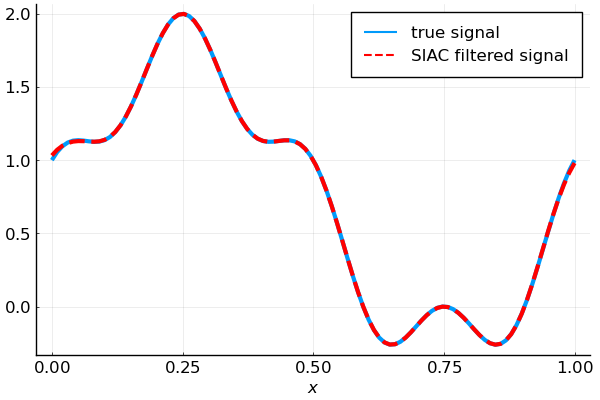

"/Users/janglaubitz/src/paper-2025-Bayesian-SIAC-Filter/Code/results/results_differentKernels/differentKernels_filteredFunction_k4_N100.pdf"

In [191]:
# Check SIAC filter applied on the underlying true function
pyplot() 
# Create the plot for the underlying true function
plot_fx_check = Plots.plot( 
    xx, fx; 
    label="true signal", lw=3, ls=:solid 
)
# Add SIAC filtered data 
Plots.plot!(plot_fx_check, 
    xx, fx_true_filter;     
    label="SIAC filtered signal",
    lw=3, ls=:dash, lc=:red 
)
# Make some cosmetic changes to the plot 
Plots.plot!(plot_fx_check,
    xlabel=L"x",  
    tickfontsize=12, labelfontsize=12, legendfontsize=12 # font sizes 
)
# Display the plot
display(plot_fx_check)
# Save the plot
savefig(plot_fx_check, joinpath(results_dir, "differentKernels_filteredFunction_k$(k)_N$(N).pdf"))  # Save as PNG

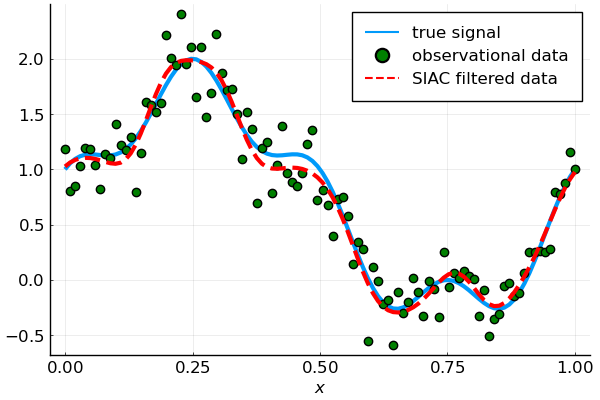

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


"/Users/janglaubitz/src/paper-2025-Bayesian-SIAC-Filter/Code/results/results_differentKernels/differentKernels_data_k5_N102.pdf"

In [173]:
# Plot underlying true function, noisy data, and filtered data
pyplot() 
# Create the plot for the underlying true function
plot_fx = Plots.plot( 
    xx, fx; 
    label="true signal", lw=3, ls=:solid 
)
# Add noisy data  
Plots.scatter!(plot_fx, 
    xx, fx_noisy; 
    label="observational data", 
    markercolor = :green, markersize = 6, marker_alpha = 0.6 
)
# Add SIAC filtered noisy data 
Plots.plot!(plot_fx, 
    xx, fx_noisy_filter;     
    label="SIAC filtered data",
    lw=3, ls=:dash, lc=:red 
)
# Make some cosmetic changes to the plot 
Plots.plot!( plot_fx,
    xlabel=L"x",  
    tickfontsize=12, labelfontsize=12, legendfontsize=12 # font sizes 
)
# Display the plot
display(plot_fx)
# Save the plot
savefig(plot_fx, joinpath(results_dir, "differentKernels_data_k$(k)_N$(N).pdf"))  # Save as PNG

# Set up the statistical model 

We consider the following model: 
\begin{align*}
    \mathbf{fx\_noisy} & \sim \mathcal{N}(F\mathbf{u},\sigma^2*I) = \mathcal{N}(F\mathbf{u},\alpha^{-1}*I), \\
    R \mathbf{u} & \sim \mathcal{N}(\mathbf{0},\beta^{-1}*I), \\ 
\end{align*}
where $R$ is the regularization operator. 
The associated posterior log PDF is 
$$            
                -\frac{\alpha}{2}  \| F\mathbf{u} - \mathbf{fx\_noisy} \|_2^2 
                -\frac{\beta}{2}  \| R\mathbf{u} \|_2^2 
                - d \alpha - d\beta + (\frac{N}{2}+c-1)\log \alpha + (\frac{N}{2}+c-1)\log \beta.
$$

In [174]:
# Set up the statistical model

# regularization operator
R = Matrix(1.0I, N, N) - Ffil
c = 1
d = 1.0e-3

# Define the posterior log-PDF for both unknown signal and hyperparameters  
function logpdf_posterior(z, F, fx_noisy, R, c, d, N) 
    u, α, β = z[1:end-2], z[end-1], z[end]

    if α<=0 || β<=0
        logpdf = -Inf
    else
        logpdf = -(.5α)*norm(F*u-fx_noisy)^2 -(.5β)*norm(R*u)^2 - d*α - d*β + (N/2+c-1)*log(α) + (N/2+c-1)*log(β)
    end
    
    return logpdf
end

println("Statistical model has been set up!")

Statistical model has been set up!


# MAP estimate

In [175]:
function BCD_1d_scalar(F, y, R, c, d, QUIET)

    t_start = time()  # Measure time

    # Global constants and defaults
    MIN_ITER = 0
    MAX_ITER = 1000
    ABSTOL = 1e-8
    RELTOL = 1e-4

    # Data preprocessing
    m, n = size(F)  # number of (indirect) measurements and pixels
    k = size(R, 1)  # number of outputs of the regularization operator
    FtF = sparse(F' * F)  # product corresponding to the forward operator
    Fty = F' * y  # forward operator applied to the indirect data

    # Initial values for the inverse variances and the mean and others
    aalpha = 0.1
    bbeta = 1
    mu = zeros(n)
    mu_OLD = zeros(n)  # mean

    C_inv = Matrix(1.0I, n, n)

    abs_error = 0
    rel_error = 0

    if !QUIET
        println("iter\t abs error\t abs tol\t rel error\t rel tol")
    end

    # Iterate between the update steps until convergence or max number of iterations
    for counter in 1:MAX_ITER

        # 1) Fix aalpha, bbeta, and update x
        C_inv = sparse(aalpha * FtF + bbeta * R' * R)  # update covariance matrix
        mu = C_inv \ (aalpha * Fty)  # update the mean

        # 2) Fix x, B and update aalpha
        aalpha = (m + 2 * c) / (norm(F * mu - y)^2 + 2 * d)

        # 3) Fix x, aalpha and update B
        bbeta = (n + 2 * c) / (norm(R * mu)^2 + 2 * d)

        # Store certain values in history structure
        abs_error = norm(mu - mu_OLD)^2  # absolute error
        rel_error = (norm(mu - mu_OLD) / norm(mu_OLD))^2  # relative error

        mu_OLD = mu  # store value of mu

        if !QUIET
            println("$(counter)\t $(abs_error)\t $(ABSTOL)\t $(rel_error)\t $(RELTOL)")
        end

        # Check for convergence
        if abs_error < ABSTOL && rel_error < RELTOL && counter > MIN_ITER
            break
        end

    end

    # Output the time it took to perform all operations
    if !QUIET
        println("Elapsed time: ", time() - t_start, " seconds")
    end

    return mu, C_inv, aalpha, bbeta, Dict("abs_error" => abs_error, "rel_error" => rel_error)
end

fx_BCD, C_inv, aalpha, bbeta, history = BCD_1d_scalar(F, fx_noisy, R, c, d, false );

iter	 abs error	 abs tol	 rel error	 rel tol
1	 110.05171441923022	 1.0e-8	 Inf	 0.0001
2	 0.03869491652029664	 1.0e-8	 0.00035160666714279887	 0.0001
3	 0.0046947702388546375	 1.0e-8	 4.268302104544471e-5	 0.0001
4	 0.00015073868209682364	 1.0e-8	 1.3717937433614122e-6	 0.0001
5	 5.945820530275026e-9	 1.0e-8	 5.412681099577985e-11	 0.0001
Elapsed time: 0.007276058197021484 seconds


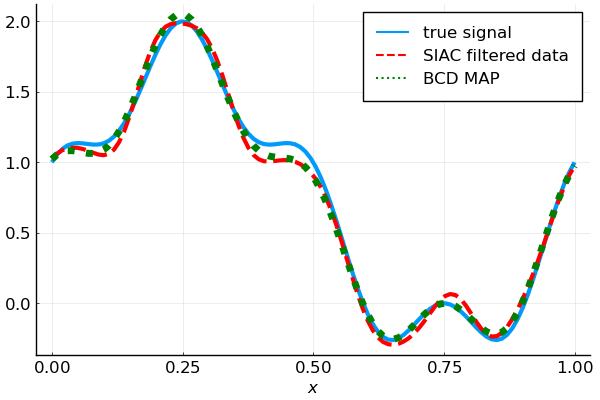

"/Users/janglaubitz/src/paper-2025-Bayesian-SIAC-Filter/Code/results/results_differentKernels/differentKernels_MAP_k5_N102.pdf"

In [176]:
# Plot underlying true function, noisy data, and MAP estimates
pyplot() 
# Create the plot for the underlying true function
plot_fx_MAP = Plots.plot( 
    xx, fx; 
    label="true signal", lw=3, ls=:solid 
)
# Add SIAC filtered noisy data 
Plots.plot!(plot_fx_MAP, 
    xx, fx_noisy_filter;     
    label="SIAC filtered data",
    lw=3, ls=:dash, lc=:red 
)
# Add MAP estimate from BCD algorithm
Plots.plot!(plot_fx_MAP, 
    xx, fx_BCD;     
    label="BCD MAP",
    lw=5, ls=:dot, lc=:green
)
# Make some cosmetic changes to the plot 
Plots.plot!(plot_fx_MAP,
    xlabel=L"x",  
    tickfontsize=12, labelfontsize=12, legendfontsize=12 # font sizes 
)

# Display the plot
display(plot_fx_MAP)
# Save the plot
savefig(plot_fx_MAP, joinpath(results_dir, "differentKernels_MAP_k$(k)_N$(N).pdf")) 

## Sampling

In [177]:
# Define the Gibbs sampling function
function gibbs_sampler(init, y, F, R, c, d, iterations)
    N = size(F, 2)  # Number of elements in u
    m = size(y, 1)  # Length of observed data y

    Ft = transpose(F)
    Rt = transpose(R)
    FtF = Ft*F
    RtR = Rt*R
    Fty = Ft*y

    # Initialize latent variables and parameters
    u = init[1:end-2]  # Initial guess for u
    α = init[end-1]  # Initial guess for alpha from Gamma prior
    β = init[end]  # Initial guess for beta from Gamma prior

    # Preallocate space to store samples
    samples_u = zeros(N, iterations)
    samples_α = zeros(iterations)
    samples_β = zeros(iterations)

    for i in 1:iterations
        # Step 1: Sample u | y, α, β
        # Σ_u_inv = α * (F' * F) + β * (R' * R)  # Posterior precision
        # Σ_u = inv(Σ_u_inv)  # Posterior covariance
        # Σ_u = 0.5*(Σ_u + Σ_u')
        # μ_u = Σ_u * (α * F' * y)  # Posterior mean of u
        # u = rand(MvNormal(μ_u, Σ_u))  # Sample u from conditional posterior
        v1 = randn(m)
        v2 = randn(N)
        w = sqrt(α)*Ft*v1 + sqrt(β)*Rt*v2
        C = α*FtF + β*RtR
        rhs = α*Fty + w
        u = C \ rhs

        # Step 2: Sample α | u, y
        residuals_y = y - F * u
        shape_α = c + m / 2  # Posterior shape for Gamma
        rate_α = d + sum(residuals_y.^2) / 2  # Posterior rate for Gamma
        α = rand(Gamma(shape_α, 1 / rate_α))  # Sample α

        # Step 3: Sample β | u, Ru
        residuals_Ru = R * u
        shape_β = c + N / 2  # Posterior shape for Gamma
        rate_β = d + sum(residuals_Ru.^2) / 2  # Posterior rate for Gamma
        β = rand(Gamma(shape_β, 1 / rate_β))  # Sample β

        # Store samples
        samples_u[:, i] = u
        samples_α[i] = α
        samples_β[i] = β
    end

    return samples_u', samples_α', samples_β'
end

gibbs_sampler (generic function with 1 method)

In [178]:
# Number of Gibbs iterations
G_iterations = 10^5

# Number of parameters
nr_params_Gibbs = N + 2
burn_in= Int64(ceil(G_iterations/10))
G_samples_aux = zeros(Float64, G_iterations+burn_in, nr_params_Gibbs, nr_chains)
G_samples = zeros(Float64, G_iterations, nr_params_Gibbs, nr_chains)


# Choose an initialization for the MCMC chains 
init_param = Array{Float64}(undef, N+2, nr_chains) 
for j in 1:nr_chains 
    init_param[:,j] = [fx_BCD; aalpha; bbeta]
end

# Use multiple threads 
@showprogress Threads.@threads for j in 1:nr_chains
    G_samples_aux[:,1:end-2,j], G_samples_aux[:,end-1,j], G_samples_aux[:,end,j] = gibbs_sampler(init_param[:,j], fx_noisy, F, R, c, d, G_iterations+burn_in)
    G_samples[:,:,j] = G_samples_aux[burn_in+1:end,:,j]
end

# Construct MCMC chains 
# Define the parameter names 
G_param_names = ["u[$i]" for i in 1:N+2]
G_param_names[end-1] = "α"
G_param_names[end] = "β"
# Create the chains object
G_chn = Chains(G_samples, Symbol.(G_param_names))

println("Gibbs sampling completed.")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:25


Gibbs sampling completed.


In [179]:
# Extract the samples of u
G_u_samples = get(G_chn, :u).u
G_u_mean = [mean(G_u_samples[i]) for i in 1:N]
G_u_lower_quantile = [quantile(vec(G_u_samples[i]), 0.05) for i in 1:N]  # 5% quantile
G_u_upper_quantile = [quantile(vec(G_u_samples[i]), 0.95 ) for i in 1:N]  # 95% quantile
# Convert to vectors for plotting
G_u_lower_quantile = collect(G_u_lower_quantile)
G_u_upper_quantile = collect(G_u_upper_quantile)

102-element Vector{Float64}:
 1.144983135469899
 1.1739561215341998
 1.1934746891520183
 1.2008615558702367
 1.1999136992534702
 1.1939839545860018
 1.1848595775931474
 1.1763944250714515
 1.177718995850054
 1.1835155773762969
 ⋮
 0.32785924125379423
 0.43693147754008044
 0.5514031435934035
 0.6640910571161275
 0.772482560131408
 0.872774037204692
 0.9619229467201568
 1.036994261696024
 1.0982598090382831

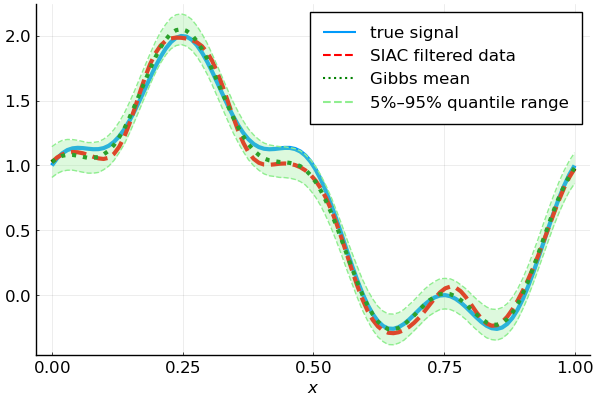

"/Users/janglaubitz/src/paper-2025-Bayesian-SIAC-Filter/Code/results/results_differentKernels/differentKernels_Gibbs_k5_N102.pdf"

In [180]:
# Plot with (i) the true signal, (ii) the SIAC-filtered data, and (iii) the Gibbs mean + quantiles.
pyplot() 
# Create the plot for the underlying true function
plot_add = Plots.plot( 
    xx, fx; 
    label="true signal", lw=3, ls=:solid 
)
# Add SIAC filtered noisy data 
Plots.plot!(plot_add, 
    xx, fx_noisy_filter;     
    label="SIAC filtered data",
    lw=3, ls=:dash, lc=:red 
)
# Add Gibbs mean
Plots.plot!(plot_add, 
    xx, G_u_mean;
    label="Gibbs mean",
    lw=3, ls=:dot, lc=:green
)
# Add Gibbs quantile
Plots.plot!(plot_add, 
    xx, G_u_lower_quantile; 
    label="5%–95% quantile range", lw=1, ls=:dash, color=:lightgreen
)
# Add Gibbs quantile
Plots.plot!(plot_add, 
    xx, G_u_upper_quantile; 
    label=false, lw=1, ls=:dash, color=:lightgreen
)
# Add shaded region between the quantiles for x
Plots.plot!(plot_add,
    xx, G_u_lower_quantile, fillrange = G_u_upper_quantile, 
    label=false, fillalpha = 0.3, lw=0, color=:lightgreen
)
# Make some cosmetic changes to the plot 
Plots.plot!(plot_add,
    xlabel=L"x",  
    tickfontsize=12, labelfontsize=12, legendfontsize=12 # font sizes 
)

# Display the plot
display(plot_add)
# Save the plot
savefig(plot_add, joinpath(results_dir, "differentKernels_Gibbs_k$(k)_N$(N).pdf")) 

In [181]:
rel_l1_err_SIAC = norm(fx_noisy_filter - fx_true, 1) / norm(fx_true, 1)
rel_l1_err_BCD = norm(fx_BCD - fx_true, 1) / norm(fx_true, 1)
rel_l1_err_mean = norm(G_u_mean - fx_true, 1) / norm(fx_true, 1)
rel_l2_err_SIAC = norm(fx_noisy_filter - fx_true) / norm(fx_true)
rel_l2_err_BCD = norm(fx_BCD - fx_true) / norm(fx_true)
rel_l2_err_mean = norm(G_u_mean - fx_true) / norm(fx_true)
rel_linf_err_SIAC = norm(fx_noisy_filter - fx_true, Inf) / norm(fx_true, Inf)
rel_linf_err_BCD = norm(fx_BCD - fx_true, Inf) / norm(fx_true, Inf)
rel_linf_err_mean = norm(G_u_mean - fx_true, Inf) / norm(fx_true, Inf)
@printf("l1-errors: SIAC=%-4.1e, MAP=%-4.1e, mean=%-4.1e \n", rel_l1_err_SIAC, rel_l1_err_BCD, rel_l1_err_mean)
@printf("l2-errors: SIAC=%-4.1e, MAP=%-4.1e, mean=%-4.1e \n", rel_l2_err_SIAC, rel_l2_err_BCD, rel_l2_err_mean)
@printf("l∞-errors: SIAC=%-4.1e, MAP=%-4.1e, mean=%-4.1e \n", rel_linf_err_SIAC, rel_linf_err_BCD, rel_linf_err_mean)

l1-errors: SIAC=6.5e-02, MAP=4.5e-02, mean=4.5e-02 
l2-errors: SIAC=6.1e-02, MAP=4.7e-02, mean=4.7e-02 
l∞-errors: SIAC=6.2e-02, MAP=5.6e-02, mean=5.8e-02 
